In [2]:
# A/B testing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('../data/online_retail_raw.csv', parse_dates=['InvoiceDate'])

df_clean = df[
    df['CustomerID'].notna() &
    ~df['InvoiceNo'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data loaded:", df_clean.shape)

Data loaded: (397884, 9)


In [3]:
from scipy import stats

# Average order value per transaction
df_clean['AOV'] = df_clean['TotalPrice']

# Split groups
uk = df_clean[df_clean['Country'] == 'United Kingdom']['AOV']
non_uk = df_clean[df_clean['Country'] != 'United Kingdom']['AOV']

print(f"UK - Mean: £{uk.mean():.2f}, Median: £{uk.median():.2f}, N: {len(uk)}")
print(f"Non-UK - Mean: £{non_uk.mean():.2f}, Median: £{non_uk.median():.2f}, N: {len(non_uk)}")

# T-test
t_stat, p_value = stats.ttest_ind(uk, non_uk)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference ✓")
else:
    print("Result: No statistically significant difference")

UK - Mean: £20.63, Median: £10.20, N: 354321
Non-UK - Mean: £36.80, Median: £17.70, N: 43563

t-statistic: -10.3067
p-value: 0.0000
Result: Statistically significant difference ✓


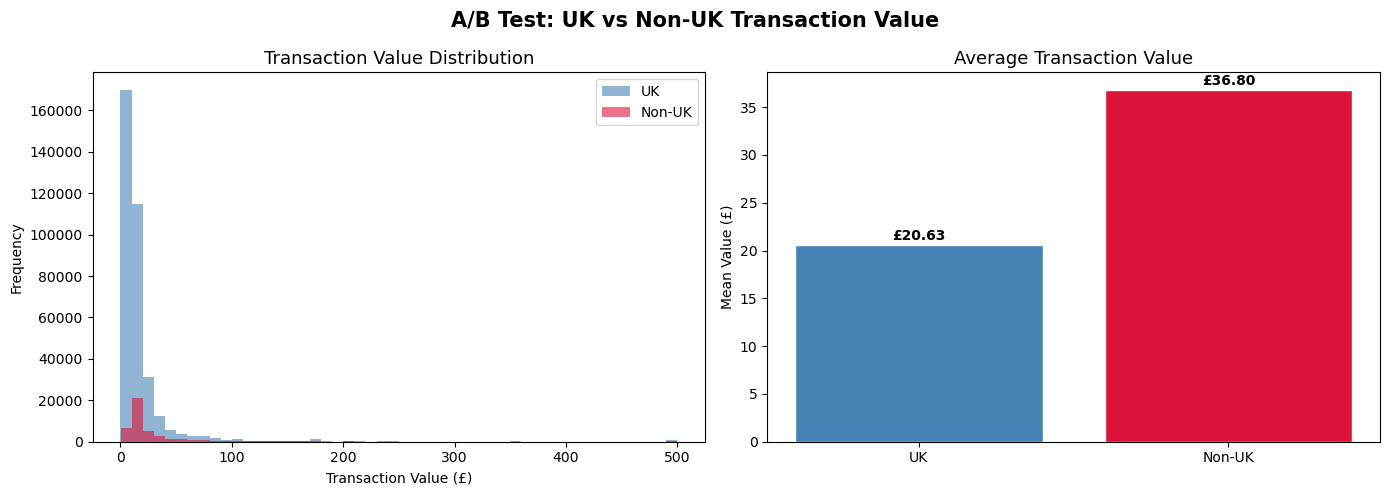

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution comparison
axes[0].hist(uk.clip(upper=500), bins=50, alpha=0.6, color='steelblue', label='UK')
axes[0].hist(non_uk.clip(upper=500), bins=50, alpha=0.6, color='crimson', label='Non-UK')
axes[0].set_title('Transaction Value Distribution', fontsize=13)
axes[0].set_xlabel('Transaction Value (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Mean comparison
means = [uk.mean(), non_uk.mean()]
axes[1].bar(['UK', 'Non-UK'], means, color=['steelblue', 'crimson'], edgecolor='white')
axes[1].set_title('Average Transaction Value', fontsize=13)
axes[1].set_ylabel('Mean Value (£)')
for i, v in enumerate(means):
    axes[1].text(i, v + 0.5, f'£{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('A/B Test: UK vs Non-UK Transaction Value', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/ab_test_uk_vs_nonuk.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **Non-UK customers spend 78% more per transaction than UK customers** (£36.80 vs £20.63), a statistically significant difference confirmed by an independent samples t-test (p < 0.0001).

- **UK dominates in transaction volume** (354k vs 43k transactions), suggesting a large domestic customer base with smaller, more frequent orders.

- Both groups show a **right-skewed distribution** — most transactions are low value with a long tail of high-value orders. Values were clipped at £500 for visualization clarity.

- **Recommendation:** Prioritize international (Non-UK) customer acquisition and retention strategies, as they generate significantly higher value per transaction.